<a href="https://colab.research.google.com/github/victormaciase/EconometriaFinanciera_MagisterFinanzasWK/blob/main/Lab4/Lab4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Laboratorio 4**

In [22]:
import numpy as np
import pandas as pd
import pandas_datareader.data as web
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import skew, kurtosis, shapiro, jarque_bera, norm, t, chi2, f
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from statsmodels.graphics.gofplots import qqplot

## **Pregunta 1**

Descarga datos mensuales desde el sitio de [Kenneth French](https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/data_library.html) para el período 2015-2026. Presenta las primeras 10 y las últimas 10 observaciones.

In [2]:
start_date = '2015-01'
end_date = '2026-06'

# 1. Descargar los 5 factores (mensual)
ff5 = web.DataReader('F-F_Research_Data_5_Factors_2x3', 'famafrench',
                     start=start_date, end=end_date)[0]

# Nombrar las 6 columnas reales
ff5.columns = ['Mkt_RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF']

# 2. Descargar el factor Momentum (MOM / Prior 2-12) (mensual)
mom = web.DataReader('F-F_Momentum_Factor', 'famafrench',
                     start=start_date, end=end_date)[0]
mom.columns = ['MOM']

# 3. Unir ambos base de 5 factores con la de momentum por fecha
ff_all = ff5.join(mom, how='inner')

# Convertir el índice a datetime y reordenar columnas
ff_all.index = pd.to_datetime(ff_all.index.astype(str))
ff_all = ff_all[['Mkt_RF', 'SMB', 'HML', 'MOM', 'RMW', 'CMA', 'RF']]

# Convertir todos los factores a formato decimal (dividir por 100)
ff_all = ff_all

In [ ]:
ff_all.head(10) # primeras 10 observaciones

,Mkt_RF,SMB,HML,MOM,RMW,CMA,RF
Date,,,,,,,
2015-01-01,-3.09,-0.93,-3.45,3.72,1.58,-1.64,0.0
2015-02-01,6.14,0.36,-1.79,-2.89,-1.10,-1.75,0.0
2015-03-01,-1.09,3.08,-0.38,2.70,0.07,-0.62,0.0
2015-04-01,0.60,-3.01,1.80,-7.26,0.05,-0.62,0.0
2015-05-01,1.38,0.82,-1.11,5.76,-1.76,-0.83,0.0
2015-06-01,-1.54,2.90,-0.82,3.00,0.35,-1.54,0.0
2015-07-01,1.57,-4.58,-4.16,10.00,0.31,-2.44,0.0
2015-08-01,-6.02,0.29,2.75,-2.14,0.66,1.29,0.0
2015-09-01,-3.06,-2.80,0.55,5.26,1.80,-0.59,0.0


In [ ]:
ff_all.tail(10)  # últimas 10 observaciones

,Mkt_RF,SMB,HML,MOM,RMW,CMA,RF
Date,,,,,,,
2025-09-01,3.39,-2.24,-0.93,4.71,-2.15,-2.24,0.33
2025-10-01,1.96,-1.62,-2.76,0.19,-5.80,-4.04,0.37
2025-11-01,-0.13,1.62,3.62,-1.71,1.66,0.62,0.30
2025-12-01,-0.36,-0.17,2.36,-2.34,0.38,0.39,0.34
2026-01-01,1.03,3.21,3.82,4.89,1.80,1.81,0.30
2026-02-01,-1.18,0.74,2.71,1.32,1.91,5.04,0.28
2026-03-01,-5.18,0.66,3.41,1.57,-2.08,-0.10,0.29
2026-04-01,9.95,0.38,-1.17,9.52,-4.30,-3.78,0.29
2026-05-01,4.91,-2.77,-2.16,1.38,-8.42,-1.40,0.31


## **Pregunta 2**

Calcula el valor mínimo, máximo, media, percentiles 25, 50 y 75 y desviación estándar de las variables descargadas en la *Pregunta 1*.

In [ ]:
# 1. Calcular las estadísticas descriptivas requeridas
stats = pd.DataFrame({
    'Mín': ff_all.min(),
    'P25': ff_all.quantile(0.25),
    'Mediana': ff_all.median(),
    'Media': ff_all.mean(),
    'P75': ff_all.quantile(0.75),
    'Máx': ff_all.max(),
    'Desv. Est.': ff_all.std()
})

stats.round(2)

,Mín,P25,Mediana,Media,P75,Máx,Desv. Est.
Mkt_RF,-13.35,-1.45,1.28,1.01,3.41,13.58,4.50
SMB,-8.18,-2.10,-0.20,-0.15,1.32,8.33,2.93
HML,-13.83,-2.15,-0.46,-0.03,2.12,12.86,3.69
MOM,-16.21,-2.22,0.52,0.35,2.93,10.00,3.98
RMW,-8.42,-1.48,0.34,0.14,1.51,7.19,2.31
CMA,-7.08,-1.63,-0.41,-0.07,1.29,7.73,2.40
RF,0.00,0.01,0.12,0.16,0.33,0.48,0.16


## **Pregunta 3**

Descarga los precios diarios de cierre ajustado de *Nvidia* y *Exxon Mobil* desde *Yahoo Finance*. Presenta las primeras 10 y las últimas 10 observaciones.


In [3]:
# 1. Obtención de datos desde Yahoo Finance
tickers = ['NVDA', 'XOM']
prices = yf.download(tickers, start='2015-01-01', end='2026-07-01', interval='1mo', auto_adjust=True, progress=False,)['Close']

In [ ]:
prices.head(10) # Primeras 10 observaciones de precios

Ticker,NVDA,XOM
Date,,
2015-01-01,0.460135,53.468971
2015-02-01,0.530712,54.561630
2015-03-01,0.503527,52.380150
2015-04-01,0.534080,53.840637
2015-05-01,0.534860,52.937637
2015-06-01,0.486039,51.694973
2015-07-01,0.482172,49.215843
2015-08-01,0.545605,47.186562
2015-09-01,0.598273,46.628403


In [ ]:
prices.tail(10)  # Últimas 10 observaciones de precios

Ticker,NVDA,XOM
Date,,
2025-09-01,186.342331,109.574249
2025-10-01,202.232071,111.138901
2025-11-01,176.774536,113.640297
2025-12-01,186.272812,117.973373
2026-01-01,190.897171,138.619202
2026-02-01,176.974152,150.497391
2026-03-01,174.196976,167.432053
2026-04-01,199.337677,152.303375
2026-05-01,210.894211,144.325470


## **Pregunta 4**

Determina los precios mínimo y máximo para cada una de las acciones.

In [ ]:
stats_precios = pd.DataFrame({
    'Mín': prices.min(),
    'Máx': prices.max()
})

stats_precios.round(2)

,Mín,Máx
Ticker,,
NVDA,0.46,210.89
XOM,25.52,167.43


## **Pregunta 5**

Construye un gráfico de líneas para ambas series de precios.

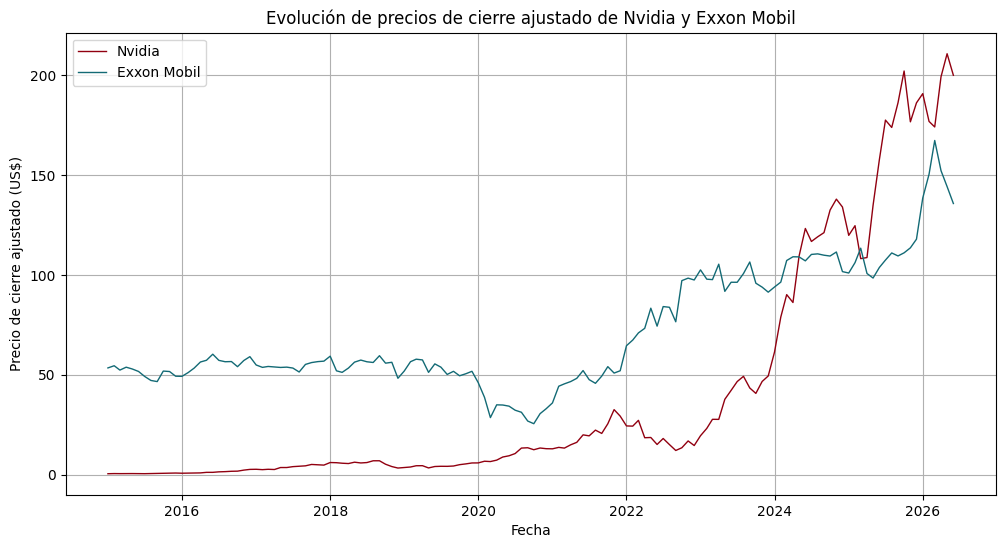

In [ ]:
# Gráfico
plt.figure(figsize=(12, 6))
plt.plot(prices.index, prices['NVDA'],
         label='Nvidia', color='#910010', linewidth=1)
plt.plot(prices.index, prices['XOM'],
         label='Exxon Mobil', color='#136A75', linewidth=1)

plt.title('Evolución de precios de cierre ajustado de Nvidia y Exxon Mobil')
plt.xlabel('Fecha')
plt.ylabel('Precio de cierre ajustado (US$)')
plt.legend()
plt.grid(True)
plt.show()

## **Pregunta 6**

Calcula el retorno mensual para ambas acciones. Presenta las primeras 10 y últimas 10 observaciones.

In [4]:
returns = prices.pct_change().dropna() * 100    # variación porcentual

In [5]:
returns.head(10)

Ticker,NVDA,XOM
Date,,
2015-02-01,15.338195,2.043517
2015-03-01,-5.122350,-3.998189
2015-04-01,6.067822,2.788203
2015-05-01,0.146077,-1.677095
2015-06-01,-9.127844,-2.347426
2015-07-01,-0.795609,-4.795696
2015-08-01,13.155849,-4.123190
2015-09-01,9.653002,-1.182901
2015-10-01,15.091218,11.284478


In [ ]:
returns.tail(10)

Ticker,NVDA,XOM
Date,,
2025-09-01,7.125121,-1.347453
2025-10-01,8.527177,1.427937
2025-11-01,-12.588278,2.250694
2025-12-01,5.373102,3.812975
2026-01-01,2.482573,17.500414
2026-02-01,-7.293466,8.568935
2026-03-01,-1.569255,11.252462
2026-04-01,14.432341,-9.035712
2026-05-01,5.797466,-5.238167


## **Pregunta 7**

Calcula el valor mínimo, máximo, media, percentiles 25, 50 y 75, desviación estándar, skewness y kurtosis de los retornos diarios. ¿Qué acción tiene mayor volatilidad?


In [ ]:
n = len(returns)  # número de observaciones
# 1. Calcular las estadísticas descriptivas requeridas
stats_returns = pd.DataFrame({
    'Mín': returns.min(),
    'P25': returns.quantile(0.25),
    'Mediana': returns.median(),
    'Media': returns.mean(),
    'P75': returns.quantile(0.75),
    'Máx': returns.max(),
    'Desv. Est.': returns.std(),
    'Obs.': n
})

# 2. Formatear como porcentaje (2 decimales) para facilitar la lectura
stats_returns.map('{:.2f}'.format)

,Mín,P25,Mediana,Media,P75,Máx,Desv. Est.,Obs.
Ticker,,,,,,,,
NVDA,-32.03,-2.56,5.51,5.37,13.62,38.54,13.14,137.00
XOM,-26.19,-2.96,0.79,0.98,4.53,26.92,7.76,137.00


In [ ]:
# Skewness
skewness_nvda = skew(returns['NVDA'], bias=True)
skewness_xom = skew(returns['XOM'], bias=True)

# Kurtosis
kurtosis_nvda = kurtosis(returns['NVDA'], fisher=True, bias=True)
kurtosis_xom = kurtosis(returns['XOM'], fisher=True, bias=True)

print("\nValores de Skewness y Kurtosis:")
print(f"Asimetría (Skewness) de NVDA: {skewness_nvda:.4f}")
print(f"Curtosis (Kurtosis) de NVDA: {kurtosis_nvda:.4f}")
print(f"\nAsimetría (Skewness) de XOM: {skewness_xom:.4f}")
print(f"Curtosis (Kurtosis) de XOM: {kurtosis_xom:.4f}")



Valores de Skewness y Kurtosis:
Asimetría (Skewness) de NVDA: -0.0432
Curtosis (Kurtosis) de NVDA: 0.1307

Asimetría (Skewness) de XOM: 0.3396
Curtosis (Kurtosis) de XOM: 2.0778


## **Pregunta 8**

Grafica la distribución de los retornos mensuales usando un histograma.

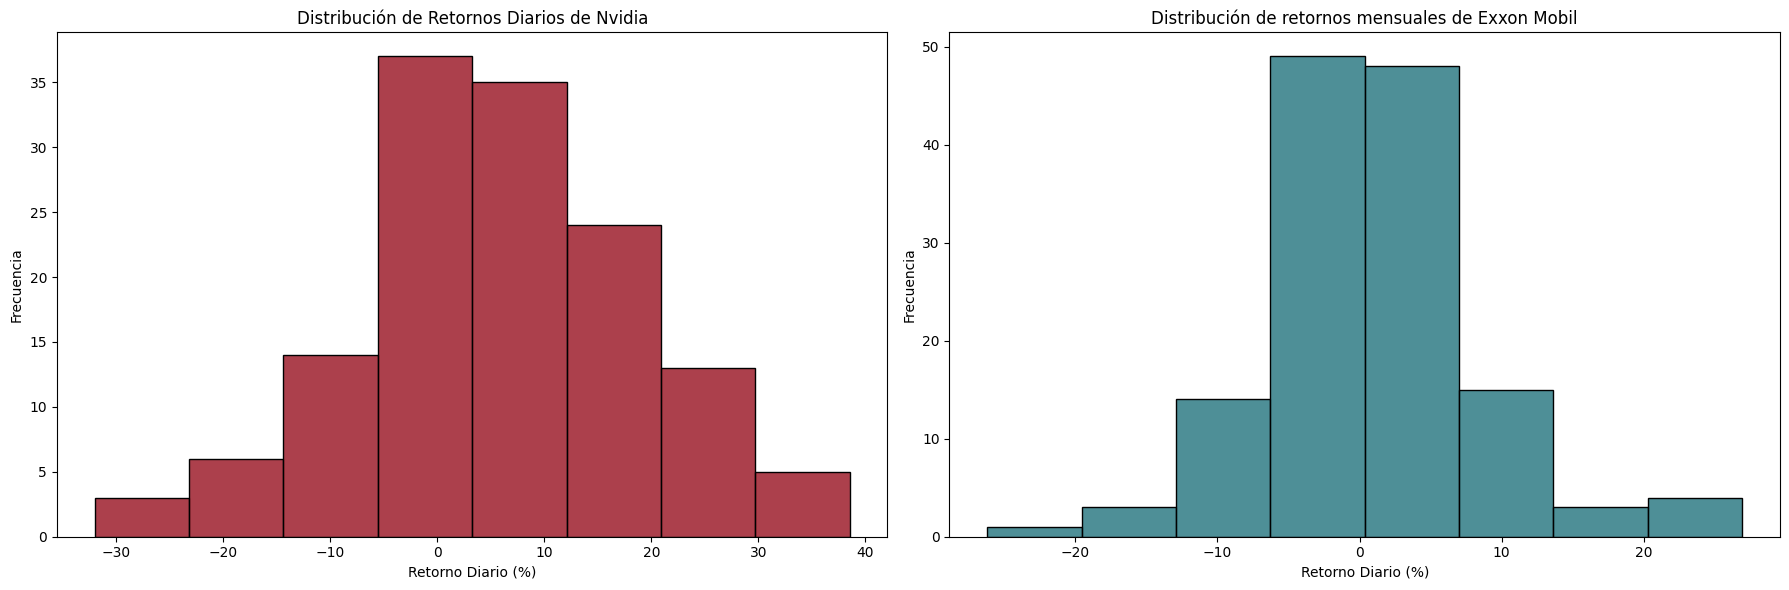

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.histplot(returns['NVDA'], bins=8, kde=False, ax=axes[0], color='#910010')
axes[0].set_title('Distribución de Retornos Diarios de Nvidia')
axes[0].set_xlabel('Retorno Diario (%)')
axes[0].set_ylabel('Frecuencia')
axes[0].grid(False)

sns.histplot(returns['XOM'], bins=8, kde=False, ax=axes[1], color='#136A75')
axes[1].set_title('Distribución de retornos mensuales de Exxon Mobil')
axes[1].set_xlabel('Retorno Diario (%)')
axes[1].set_ylabel('Frecuencia')
axes[1].grid(False)

plt.tight_layout()
plt.show()

## **Pregunta 9**

Realiza el test de Shapiro-Wilk y Jarque-Bera para testear normalidad de los retornos. Usa un nivel de significancia de 5%.

In [ ]:
# Test de Shapiro-Wilk para NVDA
stat_nvda, p_nvda = shapiro(returns['NVDA'])
print(f'Shapiro-Wilk Test para NVDA: Statistic={stat_nvda:.4f}, p-value={p_nvda:.4f}')

# Test de Shapiro-Wilk para XOM
stat_xom, p_xom = shapiro(returns['XOM'])
print(f'Shapiro-Wilk Test para XOM: Statistic={stat_xom:.4f}, p-value={p_xom:.4f}')

Shapiro-Wilk Test para NVDA: Statistic=0.9941, p-value=0.8487
Shapiro-Wilk Test para XOM: Statistic=0.9570, p-value=0.0003


Dado que el p-value para NVDA (0.8487) es mayor a 0.05, *no se rechaza $H_0$* de que los retornos de NVDA se distribuyen normalmente. Sin embargo, para XOM, el p-value (0.0003) es menor a 0.05, por lo que *se rechaza $H_0$* de que los retornos de XOM se distribuyen normalmente.

In [ ]:
# Test de Jarque-Bera para NVDA
stat_jb_nvda, p_jb_nvda = jarque_bera(returns['NVDA'])
print(f'Jarque-Bera Test para NVDA: Statistic={stat_jb_nvda:.4f}, p-value={p_jb_nvda:.4f}')

# Test de Jarque-Bera para XOM
stat_jb_xom, p_jb_xom = jarque_bera(returns['XOM'])
print(f'Jarque-Bera Test para XOM: Statistic={stat_jb_xom:.4f}, p-value={p_jb_xom:.4f}')

Jarque-Bera Test para NVDA: Statistic=0.1402, p-value=0.9323
Jarque-Bera Test para XOM: Statistic=27.2765, p-value=0.0000


La fórmula del test de Jarque-Bera es la siguiente:

$JB = n \left( \frac{S^2}{6} + \frac{K^2}{24} \right)\sim \chi^2_2$

donde:

$n$ es el número de observaciones (tamaño de la muestra).

$S$ es la asimetría (skewness) de la muestra.

$K$ es la curtosis (kurtosis) de la muestra.

La hipótesis nula ($H_0$) de este test es que los datos se distribuyen normalmente (es decir, asimetría = 0 y curtosis = 3 para una distribución normal, o exceso de curtosis = 0).

*NVDA:* Usando los datos de skewness (-0.0432) y kurtosis (0.1307) calculados en la *Pregunta 7*, y $n=137$ observaciones, se tiene:

$$JB=137\times\left(\frac{-0.0432^2}{6}+\frac{0.1307^2}{24}\right) \approx 0.1401$$

Para calcular el *p-value* debe usarse la distribución chi-cuadrado:

In [ ]:
# Definir el estadístico de Jarque-Bera y los grados de libertad
jb_estadistico = 0.1401
gl = 2

# Calcular el p-value
p_value_manual = 1 - chi2.cdf(jb_estadistico, gl)
print(f"p-value: {p_value_manual:.4f}")   # No se rechaza H0 de nornmalidad

p-value: 0.9323


*XOM:* Usando los datos de skewness (0.3396) y kurtosis (2.0778) calculados en la *Pregunta 7*, y $n=137$ observaciones, se tiene:

$$JB=137\times\left(\frac{0.3396^2}{6}+\frac{2.0778^2}{24}\right) \approx 27.28$$

Para calcular el *p-value* debe usarse la distribución chi-cuadrado:

In [ ]:
# Definir el estadístico de Jarque-Bera y los grados de libertad
jb_estadistico = 27.28
gl = 2

# Calcular el p-value
p_value_manual = 1 - chi2.cdf(jb_estadistico, gl)
print(f"p-value: {p_value_manual:.4f}")   # Se rechaza H0 de normalidad

p-value: 0.0000


## **Pregunta 10**

Crea un gráfico Q-Q plot para comparar la distribución de los retornos con una distribución normal.

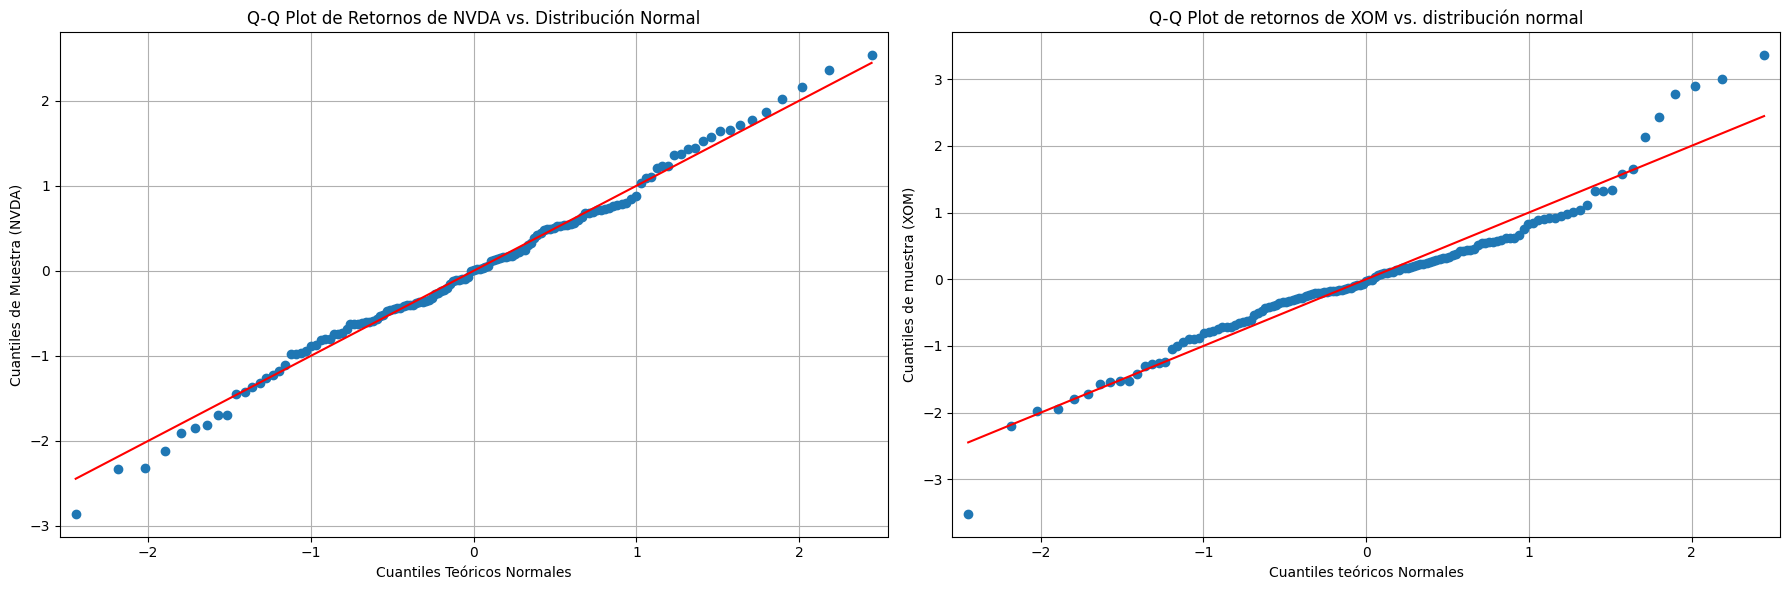

In [ ]:
# Crear los gráficos Q-Q plot
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Q-Q plot para NVDA
qqplot(returns['NVDA'], line='s', dist=norm, fit=True, ax=axes[0])
axes[0].set_title('Q-Q Plot de Retornos de NVDA vs. Distribución Normal')
axes[0].set_xlabel('Cuantiles Teóricos Normales')
axes[0].set_ylabel('Cuantiles de Muestra (NVDA)')
axes[0].grid(True)

# Q-Q plot para XOM
qqplot(returns['XOM'], line='s', dist=norm, fit=True, ax=axes[1])
axes[1].set_title('Q-Q Plot de retornos de XOM vs. distribución normal')
axes[1].set_xlabel('Cuantiles teóricos Normales')
axes[1].set_ylabel('Cuantiles de muestra (XOM)')
axes[1].grid(True)

plt.tight_layout()
plt.show()

 **¿Cómo interpretar este gráfico?**

 Si los puntos se alinean a lo largo de la línea diagonal, indica que los datos siguen una distribución normal. Las desviaciones de la línea sugieren no normalidad.


## **Pregunta 11**

Une los datos obtenidos del sitio de Kenneth French y los retornos calculados en la *Pregunta 6*. Calcula el retorno en exceso de la tasa libre de riesgo para ambas acciones.

In [6]:
# 1. Unir los retornos de las acciones con los factores de Fama-French
df = pd.merge(returns, ff_all[['Mkt_RF', 'RF', 'SMB', 'HML', 'MOM', 'RMW', 'CMA']], left_index=True, right_index=True, how='inner')

# 2. Calcular los retornos en exceso para NVDA y XOM
df['NVDA_exceso'] = df['NVDA'] - df['RF']
df['XOM_exceso'] = df['XOM'] - df['RF']

# Mostrar las primeras filas del DataFrame preparado
display(df.head())

,NVDA,XOM,Mkt_RF,RF,SMB,HML,MOM,RMW,CMA,NVDA_exceso,XOM_exceso
Date,,,,,,,,,,,
2015-02-01,15.338195,2.043517,6.14,0.0,0.36,-1.79,-2.89,-1.10,-1.75,15.338195,2.043517
2015-03-01,-5.122350,-3.998189,-1.09,0.0,3.08,-0.38,2.70,0.07,-0.62,-5.122350,-3.998189
2015-04-01,6.067822,2.788203,0.60,0.0,-3.01,1.80,-7.26,0.05,-0.62,6.067822,2.788203
2015-05-01,0.146077,-1.677095,1.38,0.0,0.82,-1.11,5.76,-1.76,-0.83,0.146077,-1.677095
2015-06-01,-9.127844,-2.347426,-1.54,0.0,2.90,-0.82,3.00,0.35,-1.54,-9.127844,-2.347426


## **Pregunta 12**

Estima por MCO el modelo CAPM:

$R_{i,t} - R_{f,t} = \alpha_i + \beta_i (R_{m,t} - R_{f,t}) + \epsilon_{i,t}$

donde:

$R_{i,t}$ es el retorno diario del activo i.

$R_{f,t}$ es la tasa libre de riesgo.

$R_{m,t}$ es el retorno diario del mercado.

$R_{i,t} - R_{f,t}$ es el exceso de retorno del activo i.

$R_{m,t} - R_{f,t}$ es el exceso de retorno del mercado (factor Mkt-RF).

$\alpha_i$ es el alfa de Jensen.

$\beta_i$ es la beta del activo i.

$\epsilon_{i,t}$ es el término de error.

In [ ]:
# Estimar el modelo CAPM para NVDA
model1_nvda = smf.ols("NVDA_exceso ~ Mkt_RF", data=df).fit()
print(model1_nvda.summary())

                            OLS Regression Results                            
Dep. Variable:            NVDA_exceso   R-squared:                       0.341
Model:                            OLS   Adj. R-squared:                  0.336
Method:                 Least Squares   F-statistic:                     69.81
Date:                Fri, 21 Aug 2026   Prob (F-statistic):           7.01e-14
Time:                        03:05:22   Log-Likelihood:                -518.16
No. Observations:                 137   AIC:                             1040.
Df Residuals:                     135   BIC:                             1046.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      3.4348      0.939      3.659      0.0

In [ ]:
# Estimar el modelo CAPM para XOM
model1_xom = smf.ols("XOM_exceso ~ Mkt_RF", data=df).fit()
print(model1_xom.summary())

                            OLS Regression Results                            
Dep. Variable:             XOM_exceso   R-squared:                       0.185
Model:                            OLS   Adj. R-squared:                  0.179
Method:                 Least Squares   F-statistic:                     30.73
Date:                Fri, 21 Aug 2026   Prob (F-statistic):           1.50e-07
Time:                        03:05:28   Log-Likelihood:                -460.69
No. Observations:                 137   AIC:                             925.4
Df Residuals:                     135   BIC:                             931.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0409      0.617      0.066      0.9

## **Pregunta 13**

Estima por MCO el modelo de 3 factores:

$R_{t} - R_{f,t} = \alpha + \beta_1 (R_{m,t} - R_{f,t}) + \beta_2 SMB_t+\beta_3 HML_t+\epsilon_{t}$

In [ ]:
# Estimar el modelo de 3 factores para NVDA
model2_nvda = smf.ols("NVDA_exceso ~ Mkt_RF + SMB + HML", data=df).fit()
print(model2_nvda.summary())

                            OLS Regression Results                            
Dep. Variable:            NVDA_exceso   R-squared:                       0.418
Model:                            OLS   Adj. R-squared:                  0.405
Method:                 Least Squares   F-statistic:                     31.84
Date:                Fri, 21 Aug 2026   Prob (F-statistic):           1.41e-15
Time:                        03:05:34   Log-Likelihood:                -509.63
No. Observations:                 137   AIC:                             1027.
Df Residuals:                     133   BIC:                             1039.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      3.3576      0.896      3.747      0.0

In [ ]:
# Estimar el modelo de 3 factores para XOM
model2_xom = smf.ols("XOM_exceso ~ Mkt_RF + SMB + HML", data=df).fit()
print(model2_xom.summary())

                            OLS Regression Results                            
Dep. Variable:             XOM_exceso   R-squared:                       0.458
Model:                            OLS   Adj. R-squared:                  0.445
Method:                 Least Squares   F-statistic:                     37.40
Date:                Fri, 21 Aug 2026   Prob (F-statistic):           1.36e-17
Time:                        03:05:37   Log-Likelihood:                -432.83
No. Observations:                 137   AIC:                             873.7
Df Residuals:                     133   BIC:                             885.3
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0495      0.512      0.097      0.9

## **Pregunta 14**

Estima por MCO el siguiente modelo:

$R_{t} - R_{f,t} = \alpha + \beta_1 (R_{m,t} - R_{f,t}) + \beta_2 SMB_t+\beta_3 HML_t+\beta_4MOM_t+\epsilon_{t}$

In [ ]:
# Estimar el modelo para NVDA
model3_nvda = smf.ols("NVDA_exceso ~ Mkt_RF + SMB + HML + MOM", data=df).fit()
print(model3_nvda.summary())

                            OLS Regression Results                            
Dep. Variable:            NVDA_exceso   R-squared:                       0.419
Model:                            OLS   Adj. R-squared:                  0.401
Method:                 Least Squares   F-statistic:                     23.77
Date:                Fri, 21 Aug 2026   Prob (F-statistic):           8.10e-15
Time:                        03:21:46   Log-Likelihood:                -509.55
No. Observations:                 137   AIC:                             1029.
Df Residuals:                     132   BIC:                             1044.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      3.4079      0.908      3.754      0.0

In [ ]:
# Estimar el modelo para XOM
model3_xom = smf.ols("XOM_exceso ~ Mkt_RF + SMB + HML + MOM", data=df).fit()
print(model3_xom.summary())

                            OLS Regression Results                            
Dep. Variable:             XOM_exceso   R-squared:                       0.464
Model:                            OLS   Adj. R-squared:                  0.448
Method:                 Least Squares   F-statistic:                     28.58
Date:                Fri, 21 Aug 2026   Prob (F-statistic):           4.17e-17
Time:                        03:21:51   Log-Likelihood:                -432.01
No. Observations:                 137   AIC:                             874.0
Df Residuals:                     132   BIC:                             888.6
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.1415      0.515      0.274      0.7

## **Pregunta 15**

Estima por MCO el siguiente modelo:

$R_{t}-R_{f,t} = \alpha + \beta_1 (R_{m,t}-R_{f,t}) + \beta_2 SMB_t+\beta_3 HML_t+\beta_4RMW_t+\beta_5CMA+\epsilon_{t}$

In [ ]:
# Estimar el modelo para NVDA
model4_nvda = smf.ols("NVDA_exceso ~ Mkt_RF + SMB + HML + RMW + CMA", data=df).fit()
print(model4_nvda.summary())

                            OLS Regression Results                            
Dep. Variable:            NVDA_exceso   R-squared:                       0.431
Model:                            OLS   Adj. R-squared:                  0.409
Method:                 Least Squares   F-statistic:                     19.82
Date:                Fri, 21 Aug 2026   Prob (F-statistic):           1.13e-14
Time:                        03:23:03   Log-Likelihood:                -508.12
No. Observations:                 137   AIC:                             1028.
Df Residuals:                     131   BIC:                             1046.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      3.3616      0.893      3.763      0.0

In [ ]:
# Estimar el modelo para XOM
model4_xom = smf.ols("XOM_exceso ~ Mkt_RF + SMB + HML + RMW + CMA", data=df).fit()
print(model4_xom.summary())

                            OLS Regression Results                            
Dep. Variable:             XOM_exceso   R-squared:                       0.482
Model:                            OLS   Adj. R-squared:                  0.462
Method:                 Least Squares   F-statistic:                     24.40
Date:                Fri, 21 Aug 2026   Prob (F-statistic):           2.67e-17
Time:                        03:23:06   Log-Likelihood:                -429.65
No. Observations:                 137   AIC:                             871.3
Df Residuals:                     131   BIC:                             888.8
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0178      0.504      0.035      0.9

## **Pregunta 16**

Estima por MCO el siguiente modelo:

$R_{t}-R_{f,t} = \alpha + \beta_1 (R_{m,t}-R_{f,t}) + \beta_2 SMB_t+\beta_3 HML_t+\beta_4MOM_t+\beta_5RMW_t+\beta_6CMA+\epsilon_{t}$

In [7]:
# Estimar el modelo para NVDA
model5_nvda = smf.ols("NVDA_exceso ~ Mkt_RF + SMB + HML + MOM + RMW + CMA", data=df).fit()
print(model5_nvda.summary())

                            OLS Regression Results                            
Dep. Variable:            NVDA_exceso   R-squared:                       0.431
Model:                            OLS   Adj. R-squared:                  0.404
Method:                 Least Squares   F-statistic:                     16.39
Date:                Fri, 21 Aug 2026   Prob (F-statistic):           5.33e-14
Time:                        13:23:15   Log-Likelihood:                -508.12
No. Observations:                 137   AIC:                             1030.
Df Residuals:                     130   BIC:                             1051.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      3.3662      0.906      3.714      0.0

In [8]:
# Estimar el modelo para XOM
model5_xom = smf.ols("XOM_exceso ~ Mkt_RF + SMB + HML + MOM + RMW + CMA", data=df).fit()
print(model5_xom.summary())

                            OLS Regression Results                            
Dep. Variable:             XOM_exceso   R-squared:                       0.489
Model:                            OLS   Adj. R-squared:                  0.466
Method:                 Least Squares   F-statistic:                     20.77
Date:                Fri, 21 Aug 2026   Prob (F-statistic):           5.74e-17
Time:                        13:23:18   Log-Likelihood:                -428.68
No. Observations:                 137   AIC:                             871.4
Df Residuals:                     130   BIC:                             891.8
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.1190      0.508      0.235      0.8

## **Pregunta 17**

Usando la especificación de la *Pregunta 16*, testea la siguiente hipótesis para *XOM*:

$H_0:\beta_1=1$

$H_1:\beta_1\neq 1$

Usando un nivel de significancia de 5% ¿Qué puedes concluir?

**Método 1:**

Nota que en este caso, el estadístico de prueba es:

$$t=\frac{0.7640-1}{0.121}=-1.95$$

In [28]:
t_estadistico = -1.95
df = 130  # n-k-1 = 130 - grados de libertad

# Calcular el p-value
p_value_manual_t = t.cdf(t_estadistico, df) * 2  # test de dos colas
print(f"p-value manual del t-statistic: {p_value_manual_t:.4e}")

p-value manual del t-statistic: 5.3328e-02


El p-value para el test de hipótesis para el modelo de XOM es 0.053.

Dado que el p-value (0.053) es mayor que el nivel de significancia de 5% (0.05), *no se puede rechazar $H_0$*.

Esto significa que, para el modelo de XOM, no hay evidencia suficiente para concluir que el coeficiente $\beta_1$ (que corresponde a `Mkt_RF`) es estadísticamente diferente de 1.

In [30]:
# Método 2
hipotesis_xom = 'Mkt_RF=1'
t_test_result_xom = model5_xom.t_test(hipotesis_xom)

print(t_test_result_xom)


                             Test for Constraints                             
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
c0             0.7640      0.121     -1.952      0.053       0.525       1.003


## **Pregunta 18**

Usando la especificación de la *Pregunta 16*, testea la siguiente hipótesis:

$H_0:\beta_1=\beta_2=\beta_3=\beta_4=\beta_5=\beta_6=0$

$H_1:$ al menos uno de los $\beta_j$ es distinto de cero.

*Nota: El test de hipótesis no incluye el intercepto.*

Este test se denomina de *significancia global del modelo*.

> *El test de significancia global del modelo se realiza para determinar si al menos uno de los coeficientes de las variables explicativas (excluyendo el intercepto) es estadísticamente diferente de cero. Esto nos dice si el conjunto de variables explicativas tiene algún poder explicativo sobre la variable dependiente.*

*Estadístico de prueba:*

El estadístico de prueba es el F-statistic reportado en el resumen de la regresión. Este sigue una distribución F con $k$ y $n-k-1$ grados de libertad, donde $k$ es el número de regresores (sin contar el intercepto) y $n$ es el número de observaciones.

(a) Usando un nivel de significancia de 1% ¿Qué puedes concluir para el modelo de NVDA?

In [15]:
# Método 1
# Obtener el p-value y el F-statistic directamente del resumen del modelo
f_pvalue_nvda = model5_nvda.f_pvalue
f_statistic_nvda = model5_nvda.fvalue
print(f"F-statistic para el modelo de NVDA: {f_statistic_nvda:.4f}")
print(f"p-value del F-statistic para el modelo de NVDA: {f_pvalue_nvda:.4e}")

F-statistic para el modelo de NVDA: 16.3923
p-value del F-statistic para el modelo de NVDA: 5.3347e-14


In [17]:
# Método 2
# Para realizar el test de hipótesis conjunta sobre los coeficientes de los factores para NVDA:
# La hipótesis nula es que todos los coeficientes de los factores (excluyendo el intercepto) son cero.

hipotesis_nvda = 'Mkt_RF=0, SMB=0, HML=0, MOM=0, RMW=0, CMA=0'
f_test_result_nvda = model5_nvda.f_test(hipotesis_nvda)

print(f_test_result_nvda)


<F test: F=16.392318738911907, p=5.334684142871555e-14, df_denom=130, df_num=6>


**Método 3:**

Para realizar este hipótesis sin recurrir a la función en `Python`:

*Primero: Cálculo del estadístico de prueba*

El estadístico de prueba es igual a:

$$F=\frac{R^2/k}{(1-R^2)/(n-k-1)}\sim F_{k,n-k-1}$$

El valor del estadístico de prueba es:

$$F=\frac{0.431/6}{(1-0.431)/(137-6-1)}=16.41$$

*Segundo: Calcular el p-value o usar el método del valor crítico.*

In [16]:
f_estadistico = 16.41
df1 = 6  # k = 6 - grados de libertad del numerador
df2 = 130 # n-k-1 = 130 - grados de libertad del denominador

# Calcular el p-value
p_value_manual_f = 1 - f.cdf(f_estadistico, df1, df2)
print(f"p-value manual del F-statistic: {p_value_manual_f:.4e}")

p-value manual del F-statistic: 5.1847e-14


El p-value del F-statistic es $5.18\times 10^{-14}$. Dado que este p-value ($5.18\times 10^{-14}$) es menor que el nivel de significancia de 1%, *se rechaza $H_0$*.

Esto significa que, para el modelo de NVDA, al menos uno de los coeficientes de los factores *(Mkt_RF, SMB, HML, MOM, RMW, CMA)* es estadísticamente diferente de cero, lo que indica que el modelo es globalmente significativo.

(b) Usando un nivel de significancia de 1% ¿Qué puedes concluir para el modelo de XOM?

## **Pregunta 19**
Estima la especificación del modelo de la *Pregunta 16* para $NVDA$, usando las correcciones a los errores estándar dadas por `HC1`, `HC3` y `HAC`. Usando un nivel de significancia de 5% ¿Qué variables son estadísticamente significativas?

In [ ]:
# Estimar el modelo para NVDA
model5_nvda = smf.ols("NVDA_exceso ~ Mkt_RF + SMB + HML + MOM + RMW + CMA", data=df).fit(cov_type='HC1')
print(model5_nvda.summary())

                            OLS Regression Results                            
Dep. Variable:            NVDA_exceso   R-squared:                       0.431
Model:                            OLS   Adj. R-squared:                  0.404
Method:                 Least Squares   F-statistic:                     16.46
Date:                Fri, 21 Aug 2026   Prob (F-statistic):           4.78e-14
Time:                        04:02:48   Log-Likelihood:                -508.12
No. Observations:                 137   AIC:                             1030.
Df Residuals:                     130   BIC:                             1051.
Df Model:                           6                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      3.3662      0.943      3.570      0.0

In [ ]:
# Estimar el modelo para NVDA
model5_nvda = smf.ols("NVDA_exceso ~ Mkt_RF + SMB + HML + MOM + RMW + CMA", data=df).fit(cov_type='HC3')
print(model5_nvda.summary())

                            OLS Regression Results                            
Dep. Variable:            NVDA_exceso   R-squared:                       0.431
Model:                            OLS   Adj. R-squared:                  0.404
Method:                 Least Squares   F-statistic:                     14.90
Date:                Fri, 21 Aug 2026   Prob (F-statistic):           6.43e-13
Time:                        04:02:40   Log-Likelihood:                -508.12
No. Observations:                 137   AIC:                             1030.
Df Residuals:                     130   BIC:                             1051.
Df Model:                           6                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      3.3662      0.982      3.428      0.0

In [ ]:
# Estimar el modelo para NVDA
model5_nvda = smf.ols("NVDA_exceso ~ Mkt_RF + SMB + HML + MOM + RMW + CMA", data=df).fit(cov_type='HAC', cov_kwds={'maxlags': 3})
print(model5_nvda.summary())

                            OLS Regression Results                            
Dep. Variable:            NVDA_exceso   R-squared:                       0.431
Model:                            OLS   Adj. R-squared:                  0.404
Method:                 Least Squares   F-statistic:                     14.96
Date:                Fri, 21 Aug 2026   Prob (F-statistic):           5.85e-13
Time:                        04:06:02   Log-Likelihood:                -508.12
No. Observations:                 137   AIC:                             1030.
Df Residuals:                     130   BIC:                             1051.
Df Model:                           6                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      3.3662      1.058      3.183      0.0

## **Pregunta 20**
Estima la especificación del modelo de la *Pregunta 16* para $XOM$, usando las correcciones a los errores estándar dadas por `HC1`, `HC3` y `HAC`. Usando un nivel de significancia de 5% ¿Qué variables son estadísticamente significativas?